<h1>Project 1: Gravitational Physics</h1>

<h3>Imports</h3>

In [2]:
from vpython import *
import matplotlib.pyplot as plt

C:\Users\auher\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

<h3>Constants</h3>

In [92]:
#Give g a negative y component of 9.8 m/s^2
g = vector(0, -9.8, 0)

#Delta t will remain the same for consistency
#This value ensures a smooth and stable visual without being too demanding
deltat = 0.005

The metric system will be used for all units, including meters (m) for distances, m/s for velocities, and m/s^2 for acceleration

<h2>1a. Ball falling</h2>

<h3>Ball Falling Simulation</h3>

When the code below is run, it simulates a ball falling down at the correct speed down through a floor. The scene is made so that the ball's position is easily viewed and the increasing velocity is clear. The implicit formula is used, with velocity being updated by current velocity, gravitational accleration, and the change in time. The position uses this new velocity and the change in time to update properly. Wind resistance is ignored here and g = -9.8 m/s^2. The mass of the ball is not relevant and does not need specified

In [93]:
#Create a new canvas to view full ball falling
scene = canvas(title = 'Falling Ball', resizable = True, autoscale = True)

#Ball object with base shape
ball = sphere(pos=vector(0,0,0), radius=0.5, color=color.cyan, make_trail=True)

#Give the ball a velocity for all three directions
#Start at rest
ball.velocity = vector(0,0,0)

#Floor for reference
floor = box(pos=vector(0,-30,0), size = vector(12,0.2,12), color = color.green)

#Start at time zero
t = 0
scene.autoscale = True

#Time for simulation to run
while t < 3:
    #Set rate to look realistic
    rate(60)

    #Update ball's velocity using semi implicit form
    ball.velocity = ball.velocity + g * deltat

    #Update ball position
    ball.pos = ball.pos + ball.velocity * deltat
    t = t + deltat

<IPython.core.display.Javascript object>

<h3>Validating for known height</h3>

Here we want to set the height of the ball so that we can then find how long it took the ball to fall this amount. A floor will be placed visually to see the distance traveled and a print statement will be used to output the time taken.

In [94]:
#Height of ball we want to test
h = 30

#How long it should take
time = 2.47

In this case, we are using a height of 20 meters. At this height, using the continuous time function of X = 0.5 x g x t^2, we can rewrite this as t = sqrt(X/(0.5 x g)). Subbing in our height we get sqrt(20/(0.5 x 9.8)) = 2.02. This is the value we can check in this case

In [95]:
#Create a new canvas to view full ball falling
scene = canvas(title = 'Falling Ball', resizable = True, height = 500, autoscale = True, width = 800)

#Ball object with base shape
ball = sphere(pos=vector(0,h,0), radius=0.5, color=color.cyan, make_trail=True)

#Floor to view ball's position after certain time
floor = box(pos=vector(0,0,0), size = vector(12,0.2,12), color = color.green)

#Center scene for better view 
scene.center = ball.pos
scene.range = 8

#Give the ball a velocity for all three directions
#Start at rest
ball.velocity = vector(0,0,0)

#Time steps
deltat = 0.005

#Start at time zero
t = 0
scene.autoscale = True

#Time for simulation to run
while t < time:
    #Set rate to look realistic
    rate(60)

    #Update ball's velocity using semi implicit form
    ball.velocity = ball.velocity + g * deltat

    #Update ball position
    ball.pos = ball.pos + ball.velocity * deltat

    #Print statement once the ball hits the floor
    if ball.pos.y <= floor.pos.y:
        print(f"Ball is at 0 meters after {t} seconds")
    
    t = t + deltat

<IPython.core.display.Javascript object>

Ball is at 0 meters after 2.4699999999999696 seconds


In the print statement, we can see the time is correct, and in the simulation we can see the ball is at the bottom. This can be repeated simply by changing the h and time variable in the first code block. To validate, this was done for 10, 20, and 30 meters, but just the 30 example is shown here

<h2>1b. Ball bouncing</h2>

<h3>Bouncing Ball Simulation</h3>

For the bouncing ball simulation, the falling ball simulation is reused, but the ball is made to bounce off of the floor instead of go through. The same previous equations are used, with air resistance ignored and elastic collision assumed. The mass of the ball is not relevant and does not need specified

In [96]:
#Create a new canvas to view full ball falling
scene = canvas(title = 'Bouncing Ball', resizable = True, height = 500, autoscale = True, width = 800)

#Ball object with base shape
ball = sphere(pos=vector(0,0,0), radius=0.5, color=color.cyan, make_trail=True)

#Floor for the ball to bounce off of
floor = box(pos=vector(0,-10,0), size = vector(12,0.2,12), color = color.green)

#Give the ball a velocity for all three directions
#Start at rest
ball.velocity = vector(0,0,0)

#Start at time zero
t = 0
scene.autoscale = True

#Time for simulation to run
while t < 6:
    #Set rate to look realistic
    rate(60)

    #Update ball's velocity using semi implicit form
    ball.velocity = ball.velocity + g * deltat

    #Update ball position
    ball.pos = ball.pos + ball.velocity * deltat

    ##################
    #Check for floor bounce and reverse velocity
    ###################
    if ball.pos.y <= floor.pos.y:
        ball.velocity.y = -ball.velocity.y
    
    t = t + deltat

<IPython.core.display.Javascript object>

We can see the ball go down to the floor, and when it reaches it, bounce back up. With no resistance and elastic collision, we can see the ball returns to its original height every time, visualized by the tail. This demonstrates a ball bouncing fully

<h2>1c. Cannonball</h2>

<h3> Cannonball Simulation
</h3>

Here, a new cannon object is created as a cylinder to show a visual of the ball being shot out. We create a new angle variable that will control the direction that the ball is shot out at. The cosine of the angle is used for the x position and the sine used for the y. This, along with an initial velocity, control the ball's path. Otherwise, the physics and behaviors remain the same. No air resistance is used and collisions are elastic. The mass of the ball is not relevant here and does not need specified

In [97]:
#Create a new canvas to view cannonball launch
scene = canvas(title = 'Cannonball', resizable = True, height = 500, autoscale = True, width = 800)

###############################################
#Variable to change the cannon and launch angle
###############################################
angle = 45
launch_deg = radians(angle)

#Floor for the ball to bounce off of
floor = box(pos=vector(0,0,0), size = vector(20,0.2,12), color = color.green)

#Cannon for a better view
cannon = cylinder(pos=vector(-10, 0.4, 0), axis=vector(1*cos(launch_deg), 1*sin(launch_deg), 0), radius=0.4,
    color=color.red)

#Ball object with base shape. Start at  for simplified calclulations
ball = sphere(pos=vector(-10,0,0), radius=0.5, color=color.cyan, make_trail=True)

########################
#Speed variable to alter
########################
ball.speed = 10
#Give the ball a velocity for all three directions based on cannon angle
ball.velocity = ball.speed * norm(cannon.axis)

#Start at time zero
t = 0


#Time for simulation to run
while t < 2:
    #Set rate to look realistic
    rate(60)

    #Update ball's velocity using semi implicit form
    ball.velocity = ball.velocity + g * deltat

    #Update ball position
    ball.pos = ball.pos + ball.velocity * deltat

    #Check for bounce
    if ball.pos.y <= floor.pos.y:
        ball.velocity.y = -ball.velocity.y
    
    t = t + deltat

<IPython.core.display.Javascript object>

<h3>Validating the Cannonball's Path</h3>

Using physics equations, there are many different measurements we can check. With inelastic collisions and no air resistance, we can set the speed of the cannonball the same for many simulations and just change the launch angle. A different launch angle will change the x and y components of the ball's travel, which we can solve for and check. This website provides functions to plug into and allows calculations as well: https://www.omnicalculator.com/physics/projectile-motion. A starting height of 0 is used. For max vertical height, we will use the formula hmax =  h0 + ((V0^2 * sin^2 (alpha)) / (2g)) where V0 is initial velocity, alpha is launch angle, g = 9.8, h0 = initial height. For the range, or horizontal component, we get R=V0^2 * sin(2* alpha)/g where V0 again is intial velocity, alpha is the launch angle, g =9.8

This simulation will stop after the ball lands. For a first example, we will chose a launch angle of 30 degrees and speed of 10 m/s. Plugging into our height and range functions, we would look to expect a height of 1.275 m and a range of 8.83 m

In [99]:
#Create a new canvas to view cannonball launch
scene = canvas(title = 'Cannonball', resizable = True, height = 500, autoscale = True, width = 800)

###############################################
#Launch angle = 30 degrees
###############################################
angle = 30
launch_deg = radians(angle)

#Floor for the ball to bounce off of
floor = box(pos=vector(0,0,0), size = vector(20,0.2,12), color = color.green)

#Cannon for a better view
cannon = cylinder(pos=vector(-10, 0.4, 0), axis=vector(1*cos(launch_deg), 1*sin(launch_deg), 0), radius=0.4,
    color=color.red)

#Ball object with base shape. Start at  for simplified calclulations
ball = sphere(pos=vector(-10,0.01,0), radius=0.5, color=color.cyan, make_trail=True)

########################
#Speed = 10 m/s
########################
ball.speed = 10
#Give the ball a velocity for all three directions based on cannon angle
ball.velocity = ball.speed * norm(cannon.axis)

#Start at time zero
t = 0
###########
#Variables for height and range
###########
max_height = ball.pos.y
max_range = ball.pos.x

#Time for simulation to run
while ball.pos.y > floor.pos.y:

    #Set rate to look realistic
    rate(60)

    #Update ball's velocity using semi implicit form
    ball.velocity = ball.velocity + g * deltat

    #Update ball position
    ball.pos = ball.pos + ball.velocity * deltat

    # Update maximum height
    if ball.pos.y > max_height:
        max_height = ball.pos.y
    
    t = t + deltat
    
# Print results
range_x = ball.pos.x
print(f"Max height: {max_height} m")
print(f"Horizontal range: {range_x +10} m")

<IPython.core.display.Javascript object>

Max height: 1.2730149999999971 m
Horizontal range: 8.833459118601251 m


In the print statements, we get a correct height of 1.27m and a range of 8.83m. This validates the trajectory for these parameters

<h4>Trial 2: 70 degrees</h4>

We can use a different launch angle, here we will use 70 degrees. With this change, our new expected height is 4.5m and our expected range is 6.55 m

In [105]:
#Create a new canvas to view cannonball launch
scene = canvas(title = 'Cannonball', resizable = True, height = 500, autoscale = True, width = 800)

###############################################
#Launch angle = 30 degrees
###############################################
angle = 70
launch_deg = radians(angle)

#Floor for the ball to bounce off of
floor = box(pos=vector(0,0,0), size = vector(20,0.2,12), color = color.green)

#Cannon for a better view
cannon = cylinder(pos=vector(-10, 0.4, 0), axis=vector(1*cos(launch_deg), 1*sin(launch_deg), 0), radius=0.4,
    color=color.red)

#Ball object with base shape. Start at  for simplified calclulations
ball = sphere(pos=vector(-10,0.01,0), radius=0.5, color=color.cyan, make_trail=True)

########################
#Speed = 10 m/s
########################
ball.speed = 10
#Give the ball a velocity for all three directions based on cannon angle
ball.velocity = ball.speed * norm(cannon.axis)

#Start at time zero
t = 0
###########
#Variables for height and range
###########
max_height = ball.pos.y
max_range = ball.pos.x

#Time for simulation to run
while ball.pos.y > floor.pos.y:

    #Set rate to look realistic
    rate(60)

    #Update ball's velocity using semi implicit form
    ball.velocity = ball.velocity + g * deltat

    #Update ball position
    ball.pos = ball.pos + ball.velocity * deltat

    # Update maximum height
    if ball.pos.y > max_height:
        max_height = ball.pos.y
    
    t = t + deltat
    
# Print results
range_x = ball.pos.x
print(f"Max height: {max_height} m")
print(f"Horizontal range: {range_x +10} m")

<IPython.core.display.Javascript object>

Max height: 4.491744528505422 m
Horizontal range: 6.549685744686689 m


We once again get the correct values in our print statements of a height of 4.5 m and a range of 6.55 m, further validating this simulation

<h2>1d. Ball falling revisited</h2>

<h3>a. Logging velocity for different heights</h3>

This function will take in an intial height of the ball to drop from. The ball will be assumed to be at rest. Using semi-implicit form, the position and velocity will update accordingly. Returned from this function in order are: magnitude of maximum velocity, the velocities as a list, and the times as a list. This will allow for easy plotting of velocity vs time.

In [109]:
def velocity_log(init_height = 10):
    #Initialize ball at rest for the start
    v = 0
    t = 0
    #Start at intial height prvoided
    y = init_height

    #Arrays to hold our velocities and time to plot
    velocities = []
    times = []

    #Time for simulation to run, go until hits the ground
    while y>0:
    
        #Update ball's velocity using semi implicit form
        v = v + g.y * deltat    
        y = y + v * deltat
        t = t + deltat

        #Add tese to a list to be graphed later
        velocities.append(v)
        times.append(t)
        
    #Include max velocity for comparison    
    max_vel = max(abs(v) for v in velocities)
    #Once the ball has reached y=0, return our data
    return max_vel,velocities, times

<h4>Trial 1 : height of 30 meters</h4>

Use this for different values of the intial height to check and visualize the logic. First, with a height of 30.

The max velocity magnitude is 24.254999999999857


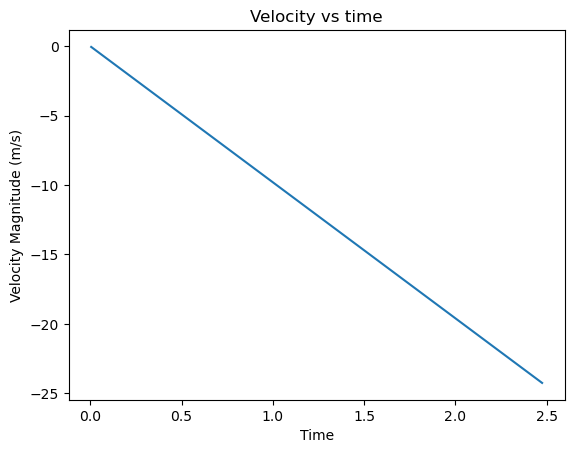

In [110]:
#Height value to check and change
height = 30

#Call our function
max_velo, v_vals, t_vals = velocity_log(height)
#Plot velocity vs time
plt.plot(t_vals, v_vals)
plt.xlabel("Time")
plt.ylabel("Velocity Magnitude (m/s)")
plt.title("Velocity vs time")

#Print the max velocity
print(f"The max velocity magnitude is {max_velo}")

We can clearly see the ball start at rest and then accelerate at the rate of g until it hits the ground. This time is what we would expect as well

<h4>Trial 2: height of 10 meters</h4>

Now, with a height of only 10 we can see the velocity does not reach the same magnitude and the overall time in air is also lower

The max velocity magnitude is 14.013999999999964


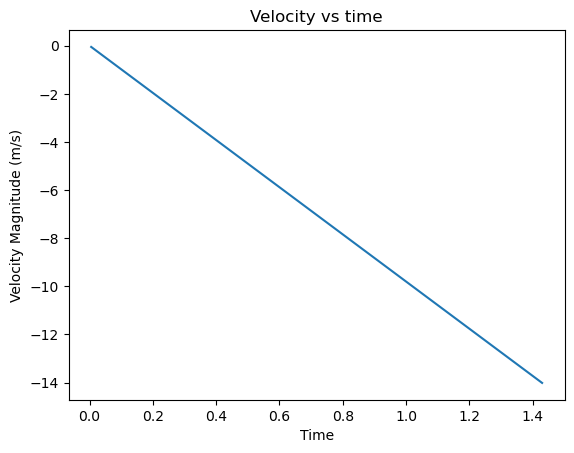

In [111]:
#Height value to check and change
height = 10

#Call our function
max_velo, v_vals, t_vals = velocity_log(height)
#Plot velocity vs time
plt.plot(t_vals, v_vals)
plt.xlabel("Time")
plt.ylabel("Velocity Magnitude (m/s)")
plt.title("Velocity vs time")

#Print the max velocity
print(f"The max velocity magnitude is {max_velo}")

<h3>b. Velocity with and without air resistance</h3>

Without air resistance, we can call our log velocity function as is. To add air resistance, we need a new factor that we will call D, or the drag force. The drag force will act against the gravitational acceleration and reduce its effect. The drag force equation at https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/falling-object-with-air-resistance/ could be used to help define a variable D. For simulation purposes, we will just wrap this all into one variable and assign it a value. A sample value for a light ball will be used

In [112]:
D = 0.03

With this value defined, we can replace our acceleration (g) in the loop with a new value that accounts for drag. Our new acceleration is defined as g - D * v * |v|, which is derived from the previous equations.

In [113]:
def velocity_log_drag(init_height = 10, D = 0.03):
    #Initialize ball at rest for the start
    v = 0
    t = 0
    #Start at intial height prvoided
    y = init_height

    #Arrays to hold our velocities and time to plot
    velocities = []
    times = []

    #Time for simulation to run, go until hits the ground
    while y>0:
        ################
        #Acceleration with drag
        ################
        a = g.y - D * v * abs(v)
        
        #Update ball's velocity using semi implicit form
        v = v + a * deltat    
        y = y + v * deltat
        t = t + deltat

        #Add tese to a list to be graphed later
        velocities.append(v)
        times.append(t)
        
    #Include max velocity for comparison    
    max_vel = max(abs(v) for v in velocities)
    #Once the ball has reached y=0, return our data
    return max_vel,velocities, times

Now that we have air resistance, we can drop the ball from high up and observe the ball reaching terminal velocity. The graphs can also be compared to the previous graphs with no resistance to observe changes in behavior. The function for terminal velcoty is defined as Vt = sqrt(g/D), and we can compute this and then check our logic

<h4>Trial 1: Drag coefficient = 0.03</h4>

Staring with our value of 0.03, we plug in to the equation. Vt = sqrt(9.8/0.03) = 18.07 m/s.

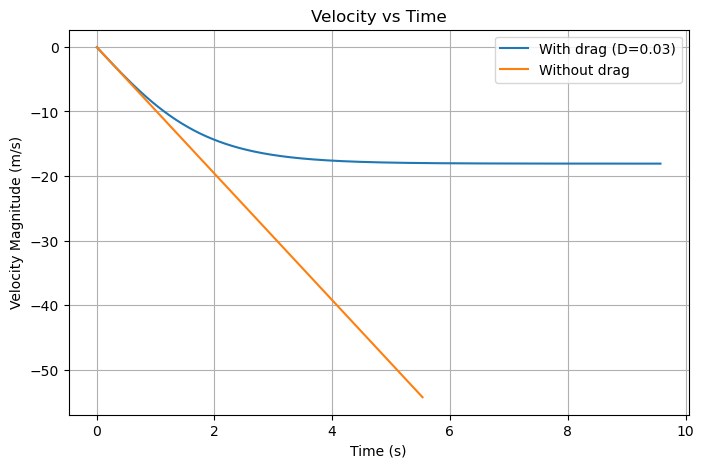

Max velocity with drag: 18.07 m/s
Max velocity without drag: 54.24 m/s


In [114]:
#Height value to check and change
height = 150
D = 0.03

#Call function with drag
max_velo_drag, v_vals_drag, t_vals_drag = velocity_log_drag(height, D)

#Call function without drag
max_velo_nodrag, v_vals_nodrag, t_vals_nodrag = velocity_log(height)

#Plot both on the same figure
plt.figure(figsize=(8,5))
plt.plot(t_vals_drag, v_vals_drag, label=f"With drag (D={D})")
plt.plot(t_vals_nodrag, v_vals_nodrag, label="Without drag")
plt.xlabel("Time (s)")
plt.ylabel("Velocity Magnitude (m/s)")
plt.title("Velocity vs Time")
plt.legend()
plt.grid(True)
plt.show()

#Print max velocities
print(f"Max velocity with drag: {max_velo_drag:.2f} m/s")
print(f"Max velocity without drag: {max_velo_nodrag:.2f} m/s")


Visually, we can see terminal velocity being reached and that the value is about what we would expect with drag added. We can also see in the print statement that the maximum velocity was 18.07, which aligns with out expectations. The velocity with no resistance never reaches a terminal velocity and continues to increase linearly

<h4>Trial 2: Drag coefficient = 0.1</h4>

We can test another drag value and set D to 0.1 for further validation. This would mean we have a lighter ball and we can expect a lower drag. For terminal velocity, Vt = sqrt(9.8/0.1) = 9.90. We run the same simulation for this new value

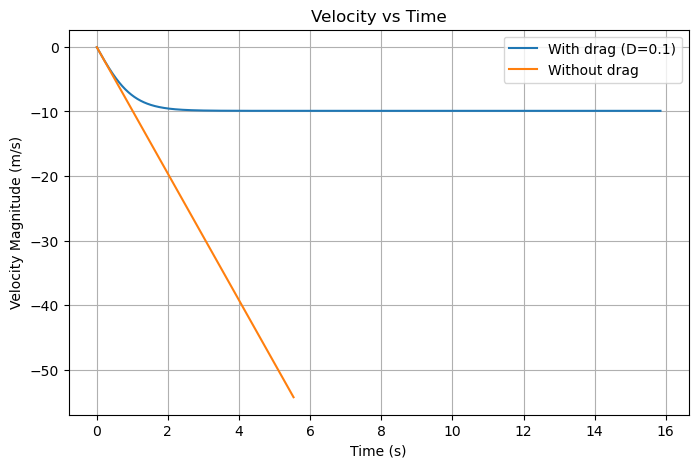

Max velocity with drag: 9.90 m/s
Max velocity without drag: 54.24 m/s


In [115]:
#Height value to check and change
height = 150
D = 0.1

#Call function with drag
max_velo_drag, v_vals_drag, t_vals_drag = velocity_log_drag(height, D)

#Call function without drag
max_velo_nodrag, v_vals_nodrag, t_vals_nodrag = velocity_log(height)

#Plot both on the same figure
plt.figure(figsize=(8,5))
plt.plot(t_vals_drag, v_vals_drag, label=f"With drag (D={D})")
plt.plot(t_vals_nodrag, v_vals_nodrag, label="Without drag")
plt.xlabel("Time (s)")
plt.ylabel("Velocity Magnitude (m/s)")
plt.title("Velocity vs Time")
plt.legend()
plt.grid(True)
plt.show()

#Print max velocities
print(f"Max velocity with drag: {max_velo_drag:.2f} m/s")
print(f"Max velocity without drag: {max_velo_nodrag:.2f} m/s")

We again get the correct terminal velocity in our drag value and the velocity graph appears correct. Witha lighter ball, the velocity levels out more quickly, while the velocity for no resistance is unchanged by a new D value and continues to increase

<h2>1e. Ball bouncing revisited</h2>

<h3>a. Logging position over time for different inital heights</h3>

Given just an initial height, we want to log the position of the ball. Assume the ball is at rest and collisions are elastic. We want to return both height and time for easy plotting

In [51]:
def position_log(initial_height = 10):
    
    #Start at time zero, at rest
    t = 0
    v = 0

    #Set initial position to our height parameter
    pos = initial_height

    #Lists to store time and position
    times = []
    positions = []
    
    #Time for simulation to run
    while t < 10:
    
        #Update ball's velocity using semi implicit form
        v = v + g.y * deltat
    
        #Update ball position
        pos = pos + v * deltat
    
        ##################
        #Check for floor bounce and reverse velocity
        ###################
        if pos <= 0:
            v = -v

        #Update time
        t = t + deltat

        #Update lists
        positions.append(pos)
        times.append(t)
        
    #Return the position and height lists
    return positions, times

Now test this log function for different intial heights and observe the heights. Start with 30 meters

Text(0.5, 1.0, 'Height vs Time')

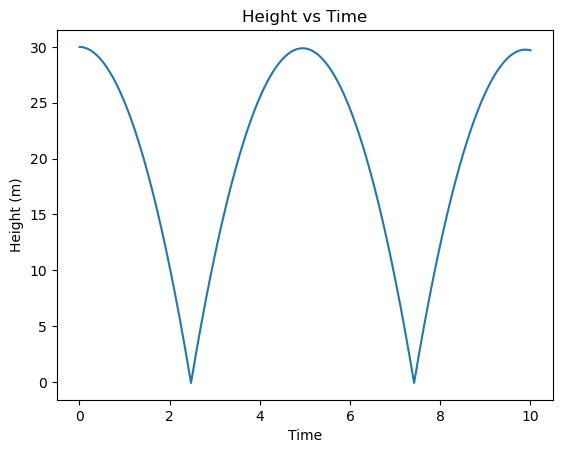

In [52]:
#Height value to check and change
height = 30

#Call our function
h_vals, t_vals = position_log(height)
#Plot velocity vs time
plt.plot(t_vals, h_vals)
plt.xlabel("Time")
plt.ylabel("Height (m)")
plt.title("Height vs Time")

Now, we will observe the heights over 50 seconds. The ball will follow an identical path but will take longer to reach y=0 and the maximum height. This helps to visualize the fully elastic collisions

Text(0.5, 1.0, 'Height vs Time')

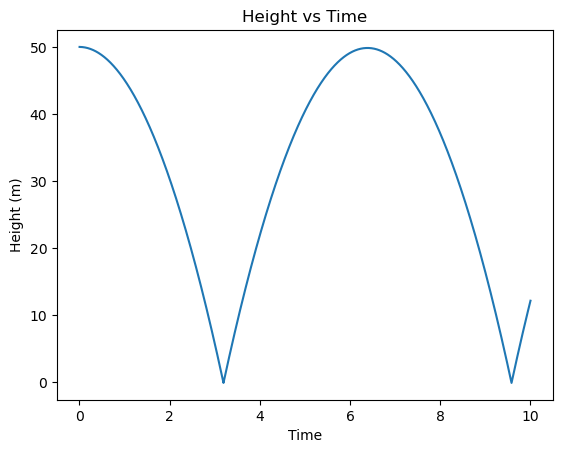

In [53]:
#Height value to check and change
height = 50

#Call the function
h_vals, t_vals = position_log(height)
#Plot velocity vs time
plt.plot(t_vals, h_vals)
plt.xlabel("Time")
plt.ylabel("Height (m)")
plt.title("Height vs Time")

<h3>b. Height for elastic vs inelastic collisions</h3>

To create an inelastic collision, loss of energy must be accounted for somehow. According to this website, https://phys.libretexts.org/Bookshelves/Classical_Mechanics/Classical_Mechanics_(Tatum)/05%3A_Collisions/5.02%3A_Bouncing_Balls, we can account for this loss of energy through a coefficient value, e. e represents the ratio of the speed of the ball after bouncing versus before bouncing. In elastic collisions, this value is always 1, but will be less than 1 in an inelastic collision. We can use the same log function earlier and adjust it to use our e value to watch how the ball would behve differently.

In [62]:
def position_log_inelastic(initial_height = 10, e = 0.8):
    
    #Start at time zero, at rest
    t = 0
    v = 0

    #Set initial position to our height parameter
    pos = initial_height

    #Set e coefficient to parameter
    e_val = e

    #Lists to store time and position
    times = []
    positions = []
    
    #Time for simulation to run
    while t < 10:
    
        #Update ball's velocity using semi implicit form
        v = v + g.y * deltat
    
        #Update ball position
        pos = pos + v * deltat
    
        ##################
        #Check for floor bounce and reverse velocity
        ###################
        if pos <= 0:
            pos=0
            ##############
            #Multiply by e for energy loss
            ##############
            v = -v * e

        #Update time
        t = t + deltat

        #Update lists
        positions.append(pos)
        times.append(t)
        
    #Return the position and height lists
    return positions, times

Now we can visulaize this new inelastic collisions by specifying the height and e coefficient, then plotting the position over time. First, height = 30, e = 0.8

<h4>Trial 1: height =  30 m, e = 0.8</h4>

Text(0.5, 1.0, 'Height vs Time')

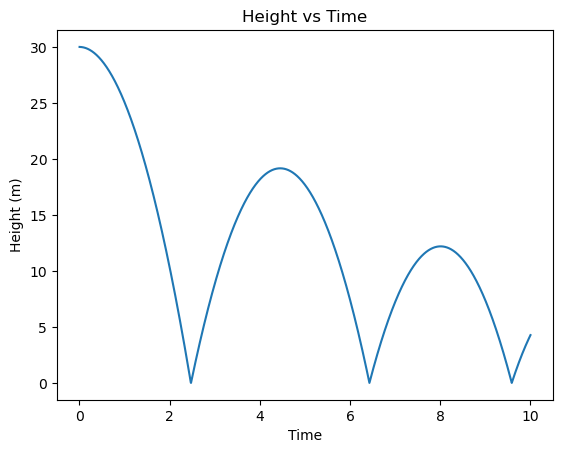

In [63]:
#Height value to check and change
height = 30
e = 0.8

#Call our function
h_vals, t_vals = position_log_inelastic(height, e)
#Plot velocity vs time
plt.plot(t_vals, h_vals)
plt.xlabel("Time")
plt.ylabel("Height (m)")
plt.title("Height vs Time")

Now we can clearly see the ball does not return to its maximum height and after each bounce, loses some of its speed. If we reduce this e value we can see this effect even more clearly

<h4>Trial 2: height =  30 m, e = 0.5</h4>

Text(0.5, 1.0, 'Height vs Time')

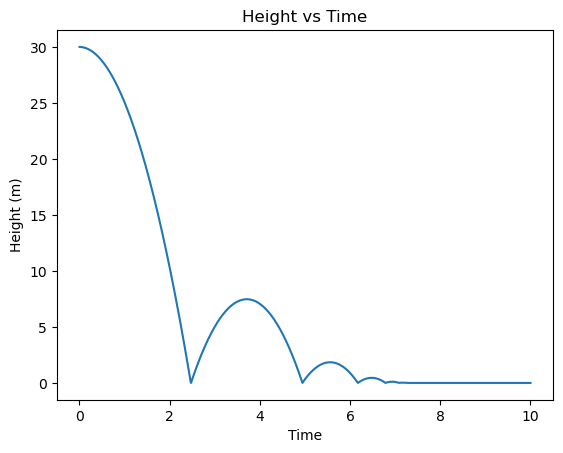

In [66]:
#Height value to check and change
height = 30
e = 0.5

#Call our function
h_vals, t_vals = position_log_inelastic(height, e)
#Plot velocity vs time
plt.plot(t_vals, h_vals)
plt.xlabel("Time")
plt.ylabel("Height (m)")
plt.title("Height vs Time")

With a lower e and more energy loss, the heights reduce quicker until eventually the ball loses all upward speed and returns to rest at the floor